**<center><font size=6>AI-driven Sentiment Analysis for Stock Market Insights<center/>**

<center><p float="center">
 <img src="https://bigblue.academy/images/image/blog/sentiment-analysis/group-153.jpg" width="720"/>
</p></center>


## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

In [ ]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.2/38.2 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.6/26.6 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 27.2 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstal

Installs essential Python libraries for numerical operations, machine learning, NLP, and data handling.

In [ ]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

Imports libraries for data manipulation, visualization, Word2Vec, Sentence Transformers, and model building/evaluation.

## **Loading the dataset**

Loads the dataset from Google Drive and creates a working copy. This preserves the original data during analysis.

In [ ]:
# Mount Google Drive to the /content/drive directory to access the files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Mounts Google Drive to allow Colab access to files. This enables loading the `stock_news.csv` dataset.

In [ ]:
# loading data into a pandas dataframe
News = pd.read_csv("/content/drive/MyDrive/GenAI_class/Datasets/stock_news.csv")

Loads `stock_news.csv` into a `News` DataFrame. This contains news articles and stock data for analysis.

In [ ]:
# creating a copy of the data
data = News.copy()

Creates a copy of the `News` DataFrame as `data`. This keeps the original `News` DataFrame unchanged.

## **Data Overview**

###**Checking the first 5 rows**

In [ ]:
data.head()

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


Displays the first 5 rows of the DataFrame. This provides a quick preview of data structure and values.

###**Checking the last 5 rows**

In [ ]:
data.tail()

,Date,News,Open,High,Low,Close,Volume,Label
344,2019-04-30,"Media mogul Oprah Winfrey, known for influencing millions with her opinions on diets and books, is considering which Democratic presidential candidate to endorse in 2020. She told the Hollywood Reporter she's ""quietly figuring out where I'm going to use my voice"" and will make a clear announcement",50.764999,50.849998,49.7775,48.70879,186139600,-1
345,2019-04-30,"European shares fell on Tuesday, with banks underperforming amid a decline in China's manufacturing activity and awaiting euro zone economic growth numbers. The pan-European STOXX 600 index dropped 0.7% while major indices fell except London's FTSE 100. Danske Bank plunged",50.764999,50.849998,49.7775,48.70879,186139600,-1
346,2019-04-30,"This article reports that the S&P 500 reached another record high close on Tuesday, marking its best four-month stretch since late 2010. Apple's strong quarterly results and positive earnings forecast helped ease concerns about the bull run's sustainability, despite a revenue miss from Google parent Alphabet. The",50.764999,50.849998,49.7775,48.70879,186139600,-1
347,2019-04-30,"The Federal Reserve is anticipated to keep interest rates unchanged in their upcoming meeting, with a likelihood of a rate cut expected later this year. The Fed Chairman's press conference may provide significant market impact as investors seek insights on economic growth and inflation. Apple's earnings report exceeded expectations, leading to a post-market surge in shares, while",50.764999,50.849998,49.7775,48.70879,186139600,-1
348,2019-04-30,"In the first quarter, South Korea's Samsung Electronics reported its weakest profit in over two years due to falls in chip prices and slowing demand for display panels. The tech giant expects improved results in the second half of 2019, driven by a pickup in memory chip and smartphone sales. However, memory chip",50.764999,50.849998,49.7775,48.70879,186139600,0


Displays the last 5 rows of the DataFrame. Useful for verifying the dataset's end and observing patterns.

###**Checking the shape of the data**

Prints the shape of the `data` DataFrame. It shows the total rows and columns.

In [ ]:
data.shape

(349, 8)

###**Checking for missing values**

In [ ]:
print(data.isnull().sum())

Date           0
News           0
Open           0
High           0
Low            0
Close          0
Volume         0
Label          0
News_Length    0
YearMonth      0
dtype: int64


Checks for missing values in each column using `.sum()`. The output indicates no missing values in the dataset.

### **Checking for duplicate values**

In [ ]:
# checking for duplicate values
print(data.duplicated().sum())

0


Identifies and counts duplicate rows. No duplicates found, ensuring data uniqueness.

## **Exploratory Data Analysis**

This cell provides a summary of the DataFrame, detailing column names, data types, and non-null counts.
It helps inspect the data's structure and completeness concisely.

Provides a concise summary of the DataFrame. This includes column names, data types, and non-null counts.

In [ ]:
#converting object column 'Date' to datetime
data['Date'] = pd.to_datetime(data['Date'])

Converts the 'Date' column to a datetime object. This is crucial for time-series analysis.

In [ ]:
# To ensure the data type of Date
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    349 non-null    datetime64[ns]
 1   News    349 non-null    object        
 2   Open    349 non-null    float64       
 3   High    349 non-null    float64       
 4   Low     349 non-null    float64       
 5   Close   349 non-null    float64       
 6   Volume  349 non-null    int64         
 7   Label   349 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 21.9+ KB


Re-displays DataFrame info after conversion. Confirms 'Date' column is now `datetime64[ns]`.

In [ ]:
# summary statistics for each numeric column
data.describe()

,Date,Open,High,Low,Close,Volume,Label
count,349,349.000000,349.000000,349.000000,349.000000,3.490000e+02,349.000000
mean,2019-02-16 16:05:30.085959936,46.229233,46.700458,45.745394,44.926317,1.289482e+08,-0.054441
min,2019-01-02 00:00:00,37.567501,37.817501,37.305000,36.254131,4.544800e+07,-1.000000
25%,2019-01-14 00:00:00,41.740002,42.244999,41.482498,40.246914,1.032720e+08,-1.000000
50%,2019-02-05 00:00:00,45.974998,46.025002,45.639999,44.596924,1.156272e+08,0.000000
75%,2019-03-22 00:00:00,50.707500,50.849998,49.777500,49.110790,1.511252e+08,0.000000
max,2019-04-30 00:00:00,66.817497,67.062500,65.862503,64.805229,2.444392e+08,1.000000
std,NaN,6.442817,6.507321,6.391976,6.398338,4.317031e+07,0.715119


Generates descriptive statistics for numerical columns. Provides insights into central tendency and dispersion.

### **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content
* Monthwise Analysis

### **Distribution of Sentiment polarity and all Numeric Variables**

Visualizes distribution of sentiment labels and numerical variables. The polarity plot shows positive, neutral, negative news balance.

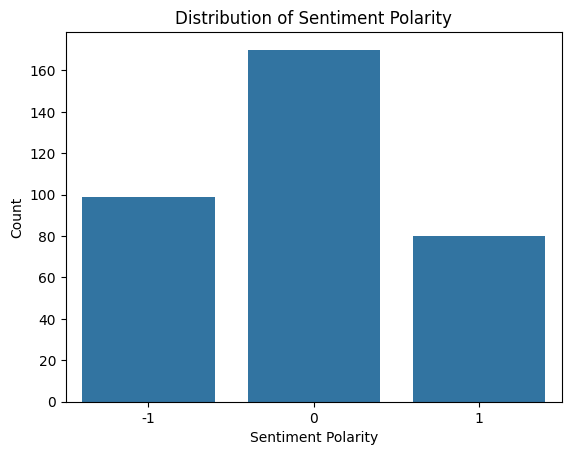

In [ ]:
#Distribution of sentiment polarity
sns.countplot(data=data, x='Label')
plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Count')
plt.show()

Generates histograms with KDEs for numeric columns. Visualizes distribution, spread, and skewness of stock prices and volume.

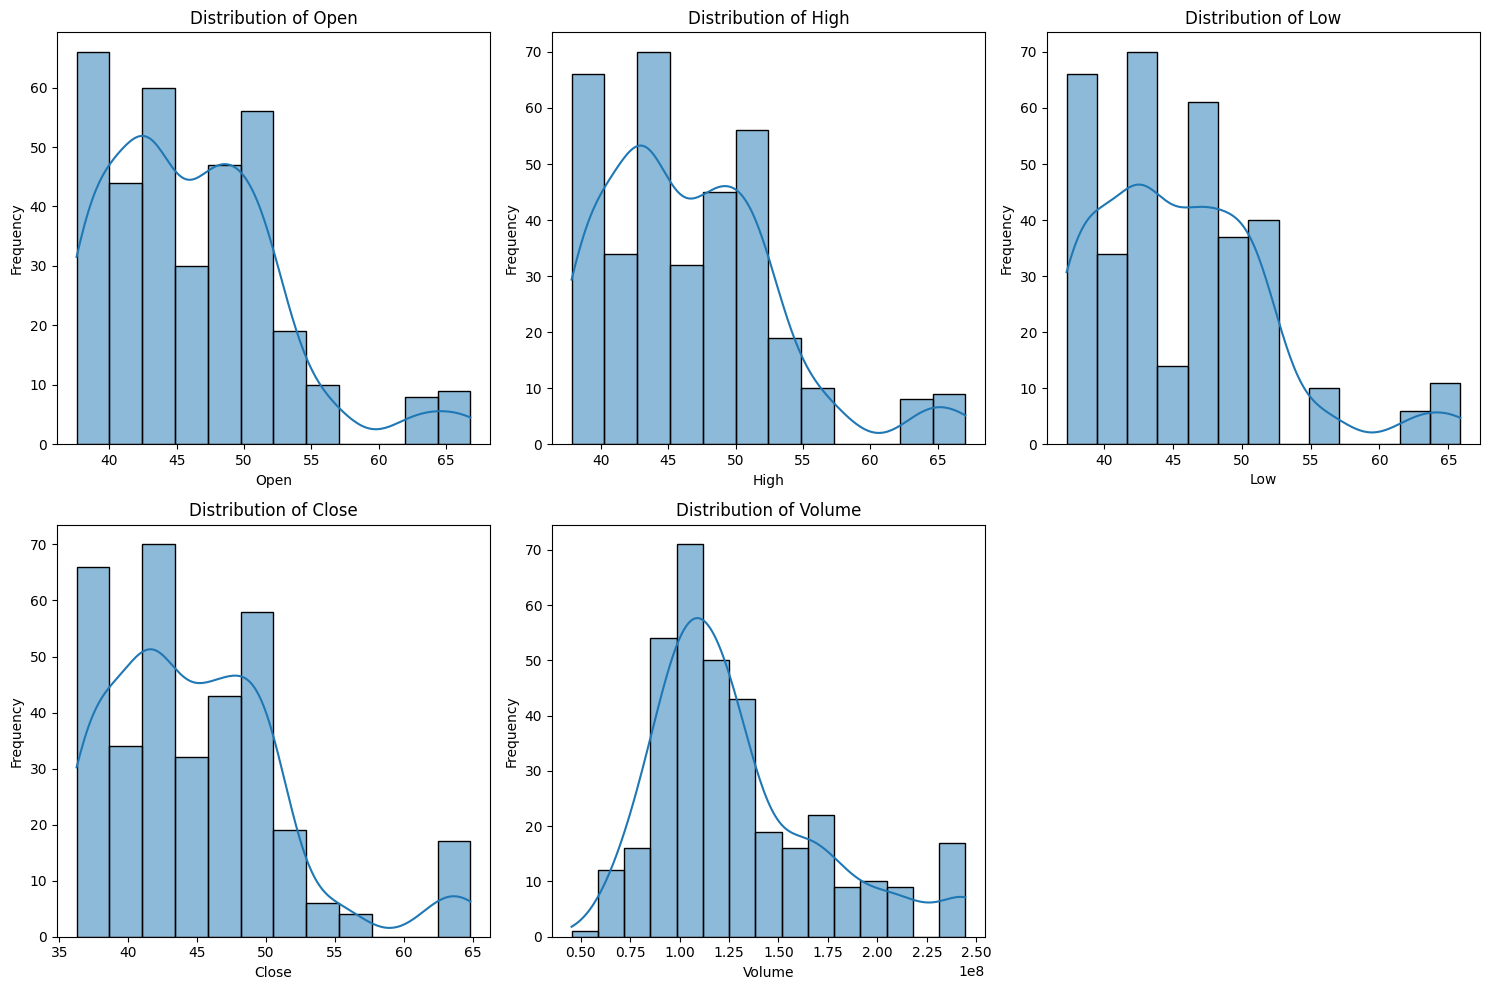

In [ ]:
#Plot Distribution of all Numeric variables
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1) # Arrange plots in a 2x3 grid
    sns.histplot(data[col], kde=True) # Use histplot for distribution, with kde for density curve
    plt.title(f'Distribution of {col}') # Set title for each plot
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

### **Distribution of the length of news content**

Analyzes news content length. Calculates and summarizes word count per article.

In [ ]:
#Compute length of news content (in words)
data['News_Length'] = data['News'].apply(lambda x: len(x.split()))

# Summary statistics of news length
display(data['News_Length'].describe())

,News_Length
count,349.000000
mean,48.349570
std,5.717324
min,18.000000
25%,45.000000
50%,49.000000
75%,52.000000
max,60.000000


Visualizes `News_Length` distribution with a histogram. Helps understand typical news article lengths.

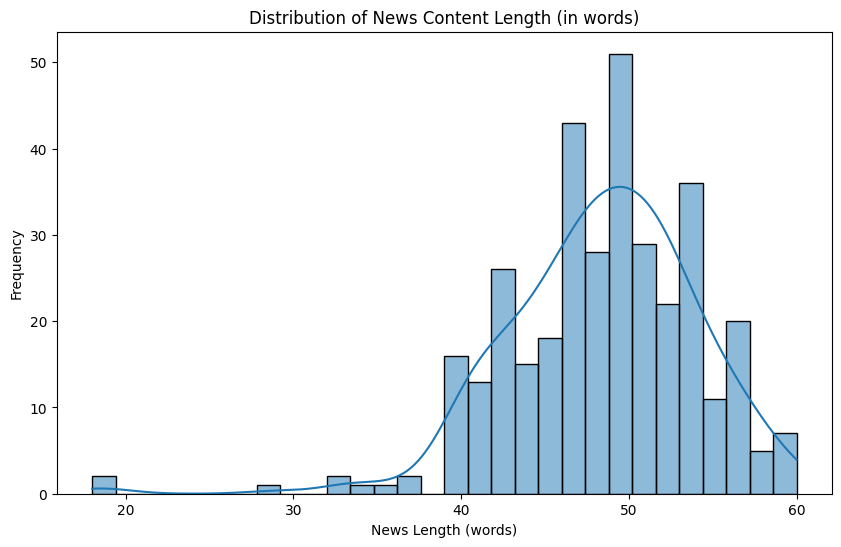

In [ ]:
#Plot distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['News_Length'], bins=30, kde=True)
plt.title('Distribution of News Content Length (in words)')
plt.xlabel('News Length (words)')
plt.ylabel('Frequency')
plt.show()

### **Monthwise Analysis**

Performs monthly analysis. Creates `YearMonth` and calculates average stock metrics.

In [ ]:
#Create a YearMonth column
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)

# Group by YearMonth and calculate averages
monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

print(monthwise_avg)

  YearMonth       High        Low       Open      Close        Volume
0   2019-01  44.024216  43.023629  43.550407  42.252099  1.393266e+08
1   2019-02  48.140754  47.365095  47.674387  46.376751  1.013622e+08
2   2019-03  48.007575  46.920933  47.566045  46.139134  1.413169e+08
3   2019-04  51.150357  50.304246  50.650277  49.462640  1.116555e+08


Generates a line plot for month-wise average stock price trends. Identifies patterns and significant price changes.

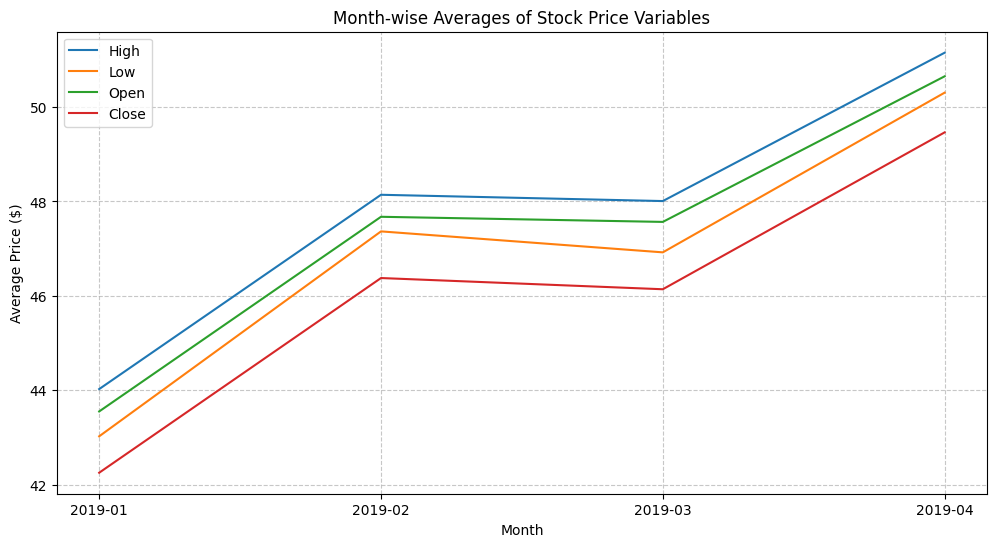

In [ ]:
#plot the monthwise averages of all price variables for better visualization
plt.figure(figsize=(12, 6))
for col in ['High', 'Low', 'Open', 'Close']:
    sns.lineplot(data=monthwise_avg, x='YearMonth', y=col, label=col)

plt.title('Month-wise Averages of Stock Price Variables')
plt.xlabel('Month')
plt.ylabel('Average Price ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

* Price Trend (High, Low, Open, Close) shows that there is a steady increase in all price measures from January to April 2019.

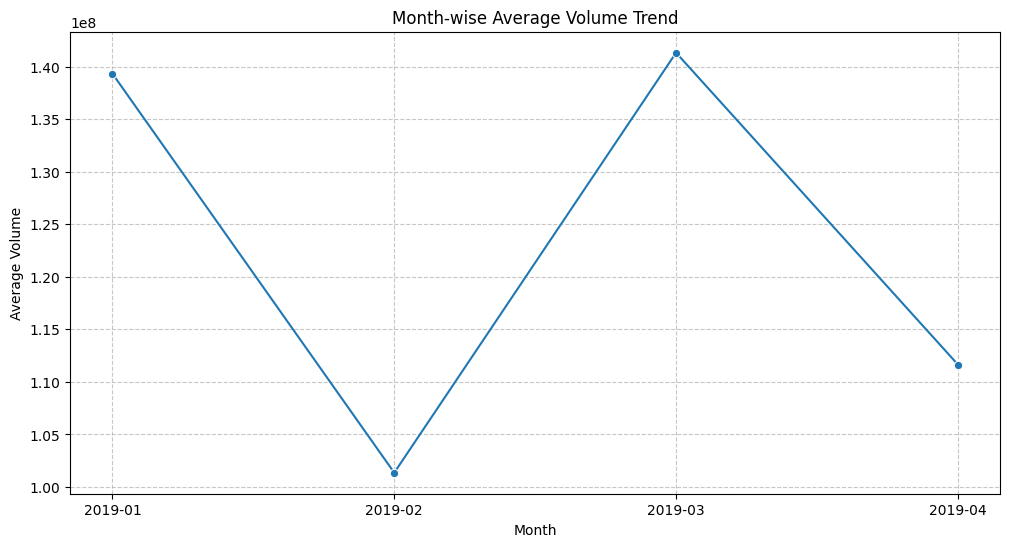

In [ ]:
#plot the trend of monthwise averages in Volume
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthwise_avg, x='YearMonth', y='Volume', marker='o')
plt.title('Month-wise Average Volume Trend')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Generates a line plot for month-wise average trading volume. Understands changes in trading activity.

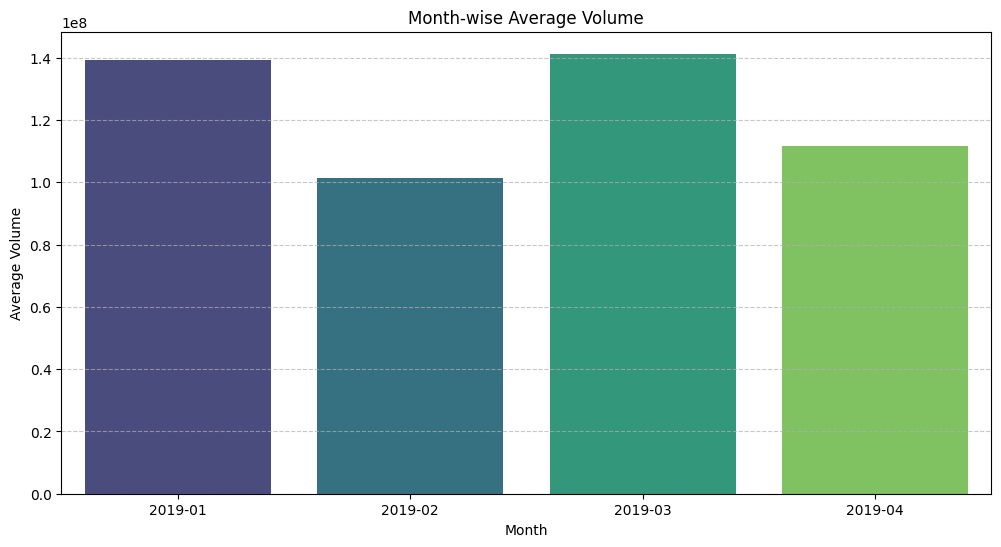

In [ ]:
# Bar plot of the monthwise averages in Volume
plt.figure(figsize=(12, 6))
sns.barplot(data=monthwise_avg, x='YearMonth', y='Volume', palette='viridis')
plt.title('Month-wise Average Volume')
plt.xlabel('Month')
plt.ylabel('Average Volume')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Creates a bar plot for month-wise average volume. Compares trading activity across months.

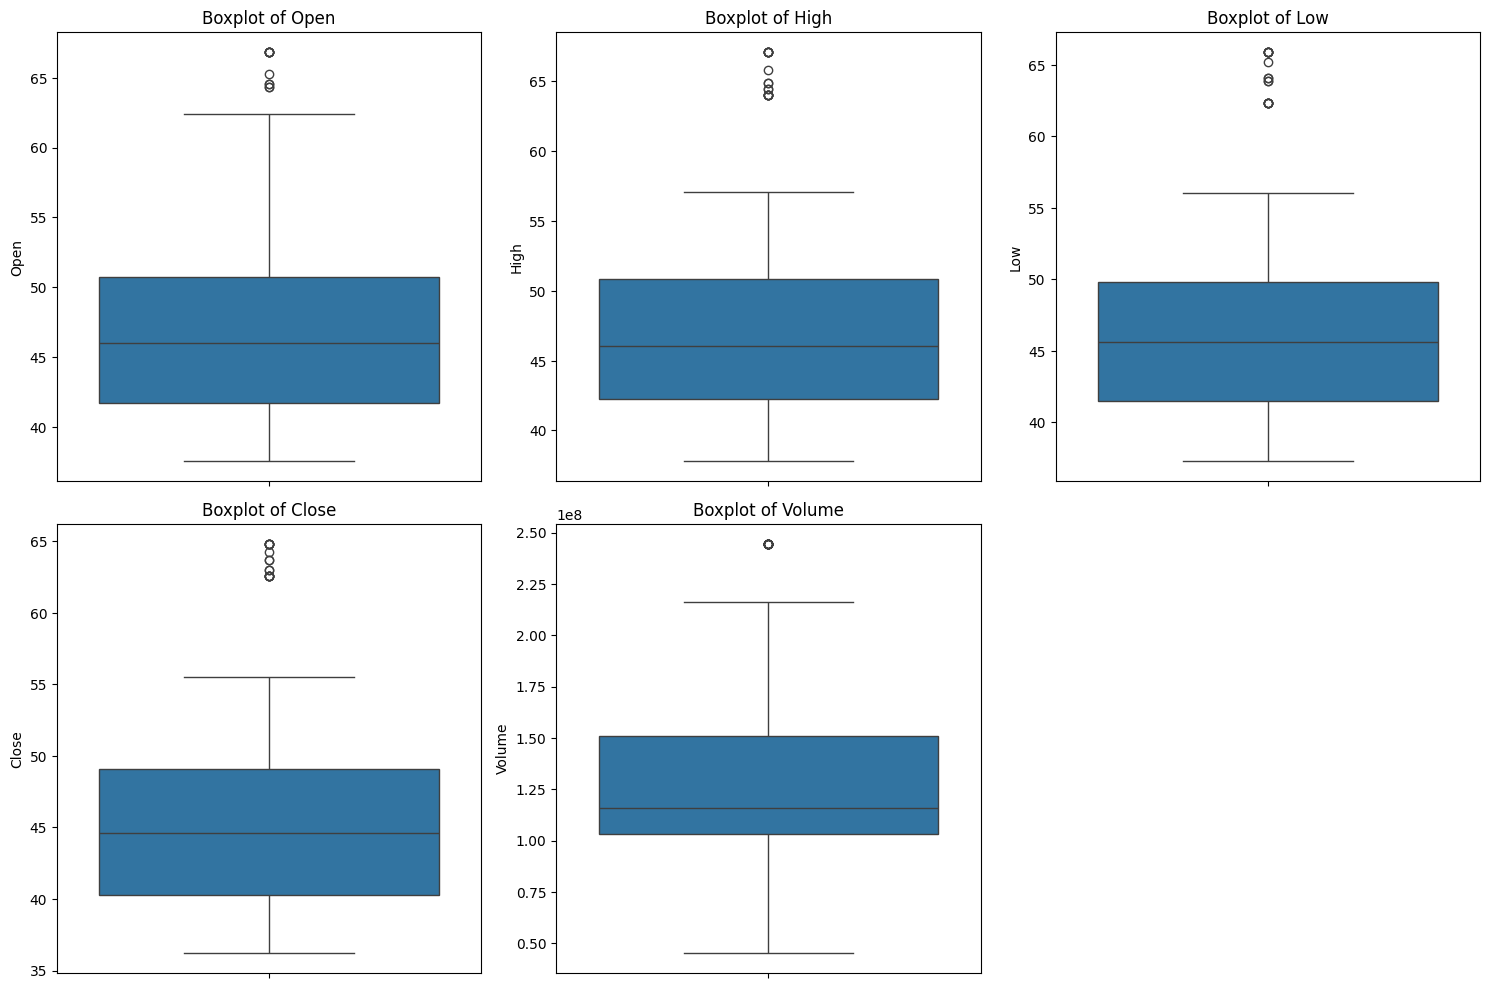

In [ ]:
# Boxplot to identify outliers
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

Generates box plots for numerical columns. Visualizes data distribution and identifies outliers.

### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price
* Distribution of News Length Across Sentiment Categories



### **Correlation**

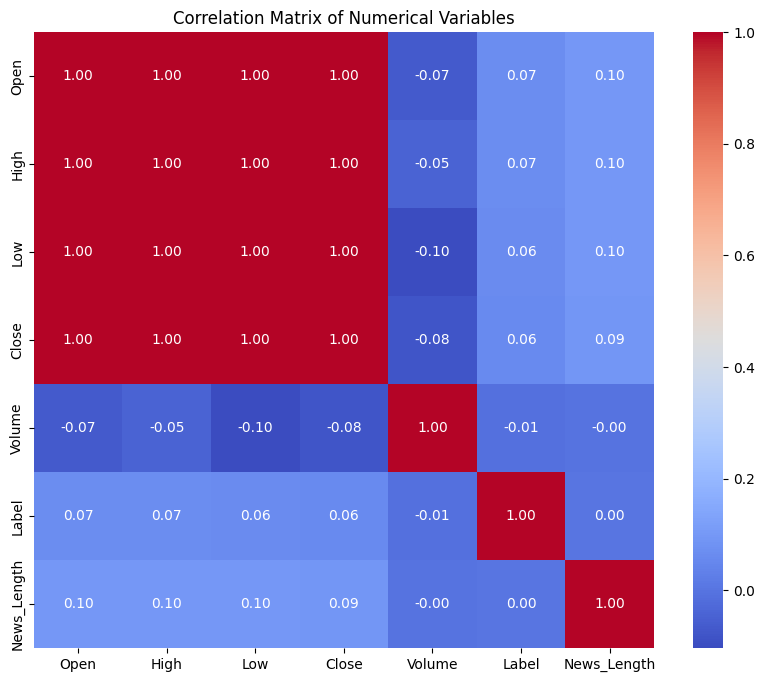

In [ ]:
# Correlation matrix to check if variables move together or have correlations
correlation_matrix = data[['Open', 'High', 'Low', 'Close', 'Volume', 'Label', 'News_Length']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

Computes and visualizes Pearson correlation matrix for numerical variables. A heatmap shows linear relationships.

### **Sentiment Polarity vs Price**

Explores relationship between sentiment polarity and stock features. Box plots compare numerical variables against sentiment labels.

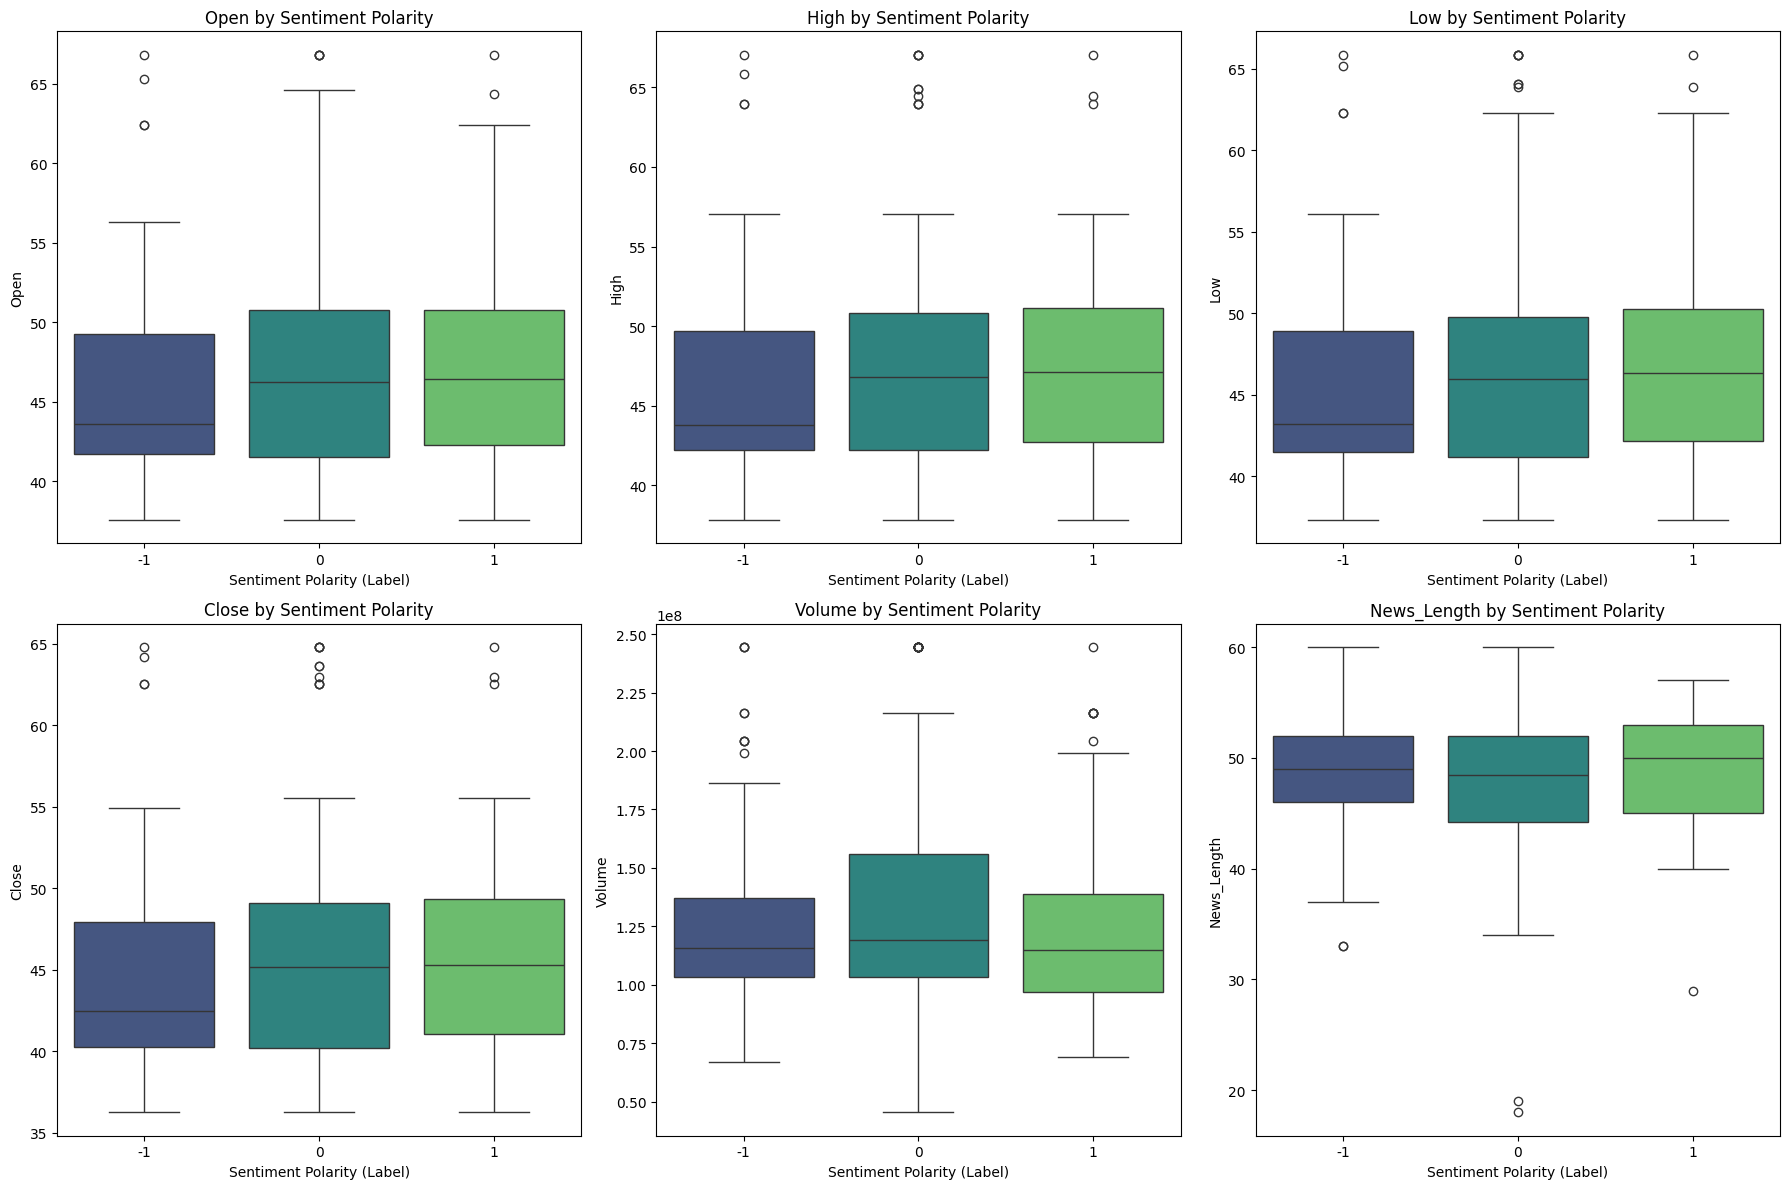

In [ ]:
# Sentiment Polarity with all numeric variables
numeric_cols_with_news_length = ['Open', 'High', 'Low', 'Close', 'Volume', 'News_Length']

plt.figure(figsize=(18, 12))
for i, col in enumerate(numeric_cols_with_news_length):
    plt.subplot(2, 3, i + 1) # Arrange plots in a 2x3 grid
    sns.boxplot(data=data, x='Label', y=col, palette='viridis')
    plt.title(f'{col} by Sentiment Polarity')
    plt.xlabel('Sentiment Polarity (Label)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### **Time Series Analysis (Date vs Price)**

Performs time-series analysis plotting stock prices against date. Crucial for understanding price trends and movements.

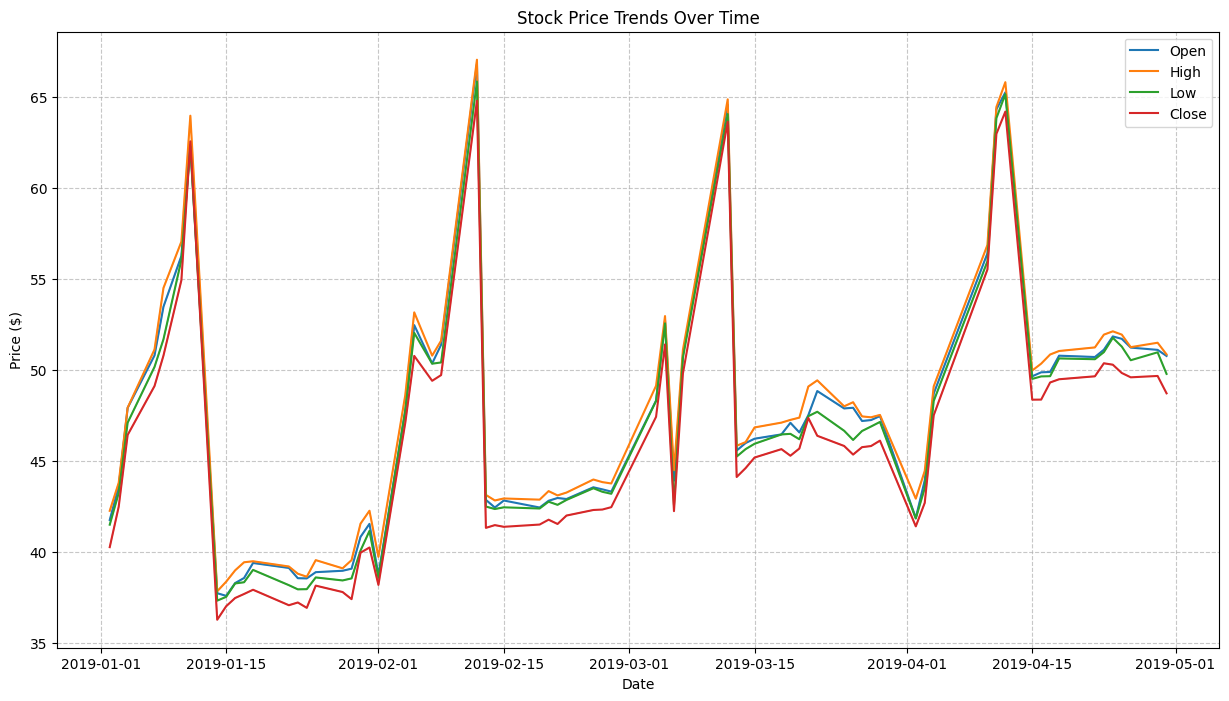

In [ ]:
#Time Series Analysis (Date vs Price columns)

plt.figure(figsize=(15, 8))
for col in ['Open', 'High', 'Low', 'Close']:
    sns.lineplot(data=data, x='Date', y=col, label=col)

plt.title('Stock Price Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### **Distribution of News Length Across Sentiment Categories**

Creates box plots for `News_Length` across sentiment categories. Determines if news length varies with sentiment.

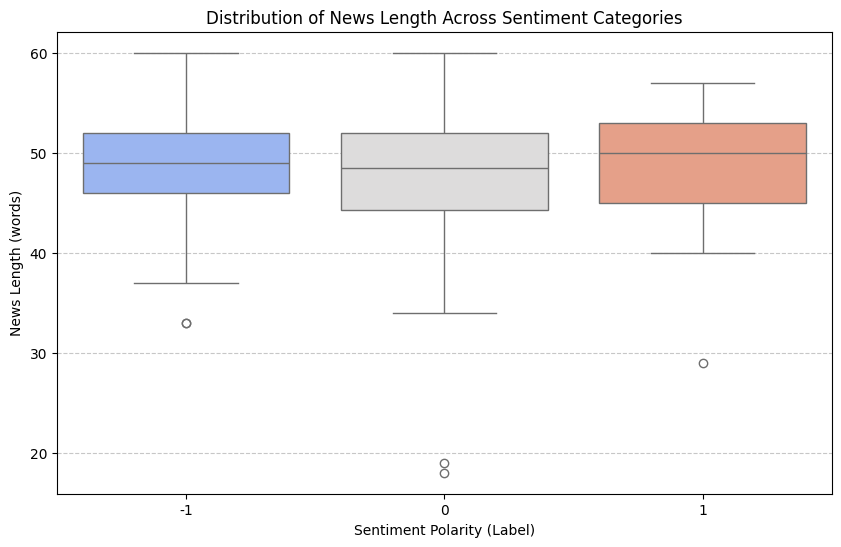

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Label', y='News_Length', palette='coolwarm')
plt.title('Distribution of News Length Across Sentiment Categories')
plt.xlabel('Sentiment Polarity (Label)')
plt.ylabel('News Length (words)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## **Data Preprocessing**

Prepares data for machine learning models. Splits data into training/testing sets and defines target variable.

* Split the dataset into training and test sets using an **80:20** ratio with **train_test_split** (random_state=42) to ensure reproducibility.

* The feature matrix  **X** contains text embeddings generated from the embedding stage.

* The dimensionality of **X** varies depending on the embedding model used.

* For each embedding type, separate **X_train and X_test splits** were created, paired with the target **y_train, y_test**.

In [ ]:
#Storing target variable
y = data['Label']

Assigns 'Label' column (sentiment polarity) to `y`. `y` is the target variable for classification models.

## **Word Embeddings**


Focuses on generating text embeddings. Uses Word2Vec and Sentence Transformers techniques.

#### **Word2Vec**

Details Word2Vec embeddings creation from news articles. Transforms text into numerical vectors for machine learning.

In [ ]:
# Creating a list of all words in our data
import nltk
nltk.download('punkt')
nltk.download('punkt_tab') # Download the missing 'punkt_tab' resource
from nltk.tokenize import word_tokenize

all_words = [word_tokenize(news.lower()) for news in data['News']]

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Downloads NLTK data and tokenizes news articles. Prepares text for Word2Vec model training.

In [ ]:
# Training the Word2Vec model
vec_size = 100 # Defining the size of the word vectors
word2vec_model = Word2Vec(all_words, vector_size=vec_size, window=5, min_count=1, workers=4, sg=0)

# Retrieving word vectors for all the words present in the model's vocabulary
words = list(word2vec_model.wv.index_to_key)

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = {word: word2vec_model.wv[word] for word in words}

# Print a sample word vector and its length
print(f"Length of words in vocabulary: {len(words)}")
print(f"Sample word vector for 'the': {word_vector_dict['the'][:5]}...") # Display first 5 elements
print(f"Length of vector for 'the': {len(word_vector_dict['the'])}")

Length of words in vocabulary: 3679
Sample word vector for 'the': [-0.4952263   0.5635413   0.22860377  0.12800814  0.08063276]...
Length of vector for 'the': 100


Trains a Word2Vec model and stores word vectors in `word_vector_dict`.

In [ ]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

Defines `average_vectorizer_Word2Vec` to convert a news article into a single vector. Achieves this by averaging Word2Vec vectors.

In [ ]:
# creating a dataframe of the vectorized documents
X = pd.DataFrame([average_vectorizer_Word2Vec(news) for news in data['News']])

display(X.head())

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
0,-0.229596,0.263132,0.106128,0.056390,0.033152,-0.421192,0.213845,0.677560,-0.168275,-0.209529,...,0.474165,-0.003032,0.046297,0.043115,0.454310,0.153029,0.182277,-0.226553,-0.028781,0.039333
1,-0.187079,0.215661,0.085877,0.046530,0.028075,-0.342711,0.176286,0.553031,-0.137376,-0.170905,...,0.385441,-0.001857,0.039776,0.036723,0.373058,0.124928,0.147171,-0.184348,-0.024011,0.033635
2,-0.215063,0.246916,0.098249,0.054186,0.031984,-0.394401,0.201667,0.636926,-0.155528,-0.198008,...,0.442698,-0.002511,0.045487,0.041164,0.427672,0.143245,0.170024,-0.210775,-0.027017,0.037973
3,-0.211635,0.245156,0.097060,0.053917,0.034599,-0.392726,0.200136,0.630825,-0.154554,-0.195173,...,0.438815,-0.003144,0.043804,0.042029,0.422534,0.139672,0.167722,-0.209777,-0.028565,0.035271
4,-0.211553,0.242960,0.097422,0.053643,0.030884,-0.386699,0.198683,0.624673,-0.153737,-0.193314,...,0.436292,-0.002710,0.042703,0.039709,0.419566,0.140973,0.168574,-0.208921,-0.025048,0.036332


Applies `average_vectorizer_Word2Vec` to news articles. `X` holds numerical Word2Vec embeddings as features.

## **Sentence Transformer**

Generates embeddings using a pre-trained Sentence Transformer model. Utilizes `BAAI/bge-base-en-v1.5` for contextualized embeddings.

####**Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 text embedding**

In [ ]:
model = SentenceTransformer('BAAI/bge-base-en-v1.5')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Initializes `SentenceTransformer` with `BAAI/bge-base-en-v1.5` weights. Produces high-quality semantic sentence embeddings.

##### Encoding the dataset

Encodes news articles using `SentenceTransformer` model. The `embedding_matrix` forms the feature set.

In [ ]:
embedding_matrix = model.encode(data['News'].tolist())

Prints `embedding_matrix` shape. Confirms number of articles and 768-dimensional embedding size.

In [ ]:
# printing the shape of the embedding matrix
embedding_matrix.shape

(349, 768)

## **Sentiment Analysis**

Builds and evaluates sentiment analysis models. Utilizes text embeddings to train and test classification models.

### **Model Evaluation Criterion**

Introduces utility functions for model evaluation. Covers `plot_confusion_matrix` and `model_performance_classification_sklearn`.

Plots a confusion matrix.
Generates key classification metrics (accuracy, recall, precision, F1-score).

##### **Utility Functions**

In [ ]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

Defines `plot_confusion_matrix` to visualize classification performance. Generates a heatmap of true vs. predicted labels.

In [ ]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

Defines `model_performance_classification_sklearn` to compute metrics. Returns Accuracy, Recall, Precision, and F1-score in a DataFrame.

## **Build Random Forest Models using different text embeddings**

Builds and evaluates Random Forest models. Uses Word2Vec and Sentence Transformer embeddings as input features.

### **Word2Vec-Random Forest Model**

Details Random Forest model construction and evaluation. Utilizes Word2Vec embeddings for sentiment classification.

In [ ]:
# Storing independent variable
X_w2v = X

Assigns Word2Vec embeddings (`X`) to `X_w2v`. `X_w2v` is the feature matrix for Word2Vec models.

In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

Splits Word2Vec embeddings and labels into train/test sets. Uses 80:20 ratio and `random_state=42` for reproducibility.

In [ ]:
# Building the model
rf_model = RandomForestClassifier(random_state=42)

# Fitting on train data
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Initializes and trains a `RandomForestClassifier`. Classifies sentiment using Word2Vec embeddings from `X_train` and `y_train`.

In [ ]:
# Predicting on train data
y_pred_train = rf_model.predict(X_train)

# Predicting on test data
y_pred_test = rf_model.predict(X_test)

Generates predictions for train/test data using `rf_model`. Predictions are crucial for performance evaluation.

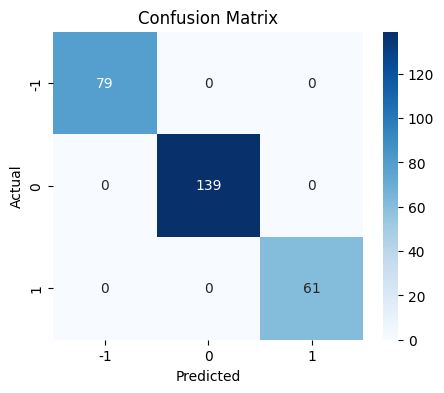

In [ ]:
plot_confusion_matrix(y_train, y_pred_train)

Calls `plot_confusion_matrix` for train data. Assesses model learning performance.

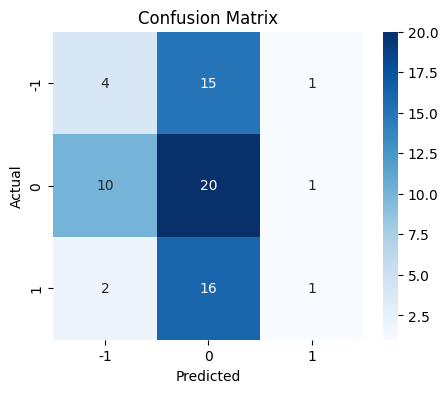

In [ ]:
plot_confusion_matrix(y_test, y_pred_test)

Calls `plot_confusion_matrix` for test data. Vital for evaluating model generalization to unseen news.

In [ ]:
train_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_Word2Vec_RF.to_string(index=False))
test_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_Word2Vec_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.357143 0.357143   0.335574 0.304195


Calculates and prints performance metrics for Word2Vec Random Forest. Provides quantitative assessment of model fit and generalization.

###**Sentence Transformer-Random Forest Model**

Builds and evaluates a Random Forest model. Uses Sentence Transformer embeddings for sentiment classification.

In [ ]:
# Storing independent variable
X = embedding_matrix


Reassigns `X` to `embedding_matrix` (Sentence Transformer embeddings). Prepares feature matrix for models.

In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Splits Sentence Transformer embeddings and labels into train/test sets. Uses 80:20 ratio and `random_state=42` for consistent splits.

In [ ]:
# Building the model
rf_model_transformer = RandomForestClassifier(random_state=42)

# Fitting on train data
rf_model_transformer.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Initializes and trains a `RandomForestClassifier`. Classifies sentiment using Sentence Transformer embeddings.

In [ ]:
# Predicting on train data
y_pred_train = rf_model_transformer.predict(X_train)

# Predicting on test data
y_pred_test = rf_model_transformer.predict(X_test)

Generates predictions for train/test sets with `rf_model_transformer`. Essential for evaluating model performance.

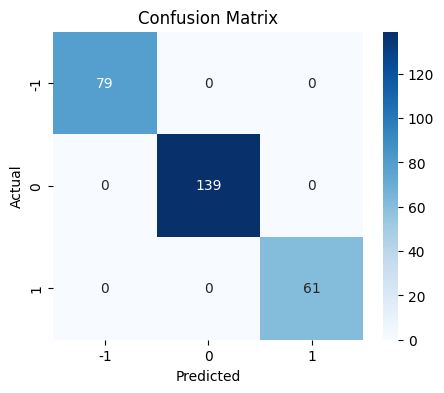

In [ ]:
plot_confusion_matrix(y_train, y_pred_train)

Displays confusion matrix for Sentence Transformer RF on training data. Assesses model performance on trained data.

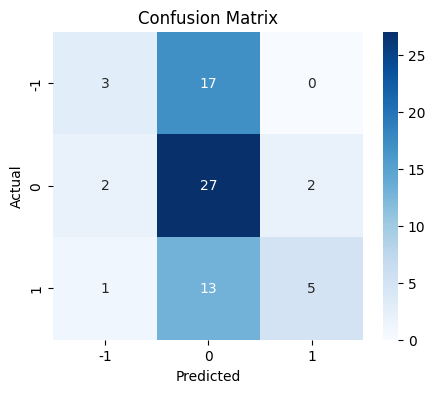

In [ ]:
plot_confusion_matrix(y_test, y_pred_test)

Displays confusion matrix for Sentence Transformer RF on test data. Critical for assessing model generalization to unseen news.

In [ ]:
train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_BAAI_RF.to_string(index=False))
test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_BAAI_RF.to_string(index=False))


Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy  Recall  Precision       F1
      0.5     0.5   0.546509 0.442083


Calculates and prints performance metrics for Sentence Transformer RF. Provides quantitative measure for comparison.

## **Building Neural Network Models using different text embeddings**

Builds and evaluates Neural Network models. Employs Word2Vec and Sentence Transformer embeddings as input features.

### **Word2Vec-Neural Network Model**

Details Neural Network model construction and evaluation. Utilizes Word2Vec embeddings for sentiment classification.

In [ ]:
#Storing independent variable
X = X

Confirms `X` is Word2Vec embeddings, preparing the feature matrix. Ensures correct input for NN training.

In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

Splits Word2Vec embeddings and labels into train/test sets. Uses 80:20 ratio and `random_state=42` for reproducibility.

In [ ]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

Maps sentiment labels to integers (0,1,2) for Keras. `y_train_mapped` and `y_test_mapped` store converted labels for NN training.

In [ ]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax') # 3 output neurons for 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,883 (417.51 KB)

 Trainable params: 106,883 (417.51 KB)

 Non-trainable params: 0 (0.00 B)

Defines a sequential Neural Network architecture. Compiles model with 'adam' optimizer and `sparse_categorical_crossentropy` loss.

In [ ]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4409 - loss: 1.0795 - val_accuracy: 0.4429 - val_loss: 1.0709
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4982 - loss: 1.0340 - val_accuracy: 0.4429 - val_loss: 1.0609
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4982 - loss: 0.9981 - val_accuracy: 0.4429 - val_loss: 1.0397
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5054 - loss: 0.9643 - val_accuracy: 0.4429 - val_loss: 1.0144
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5269 - loss: 0.9233 - val_accuracy: 0.4429 - val_loss: 0.9890
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5520 - loss: 0.8804 - val_accuracy: 0.5143 - val_loss: 0.9610
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6165 - loss: 0.8230 - val_accuracy: 0.5286 - val_loss: 0.9299
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6093 - loss: 0.8080 - val_accuracy: 0.5286 - val_loss: 0.9253


Trains the Neural Network model for 20 epochs. Uses validation data to monitor progress.

In [ ]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_pred_probs, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


Uses trained Neural Network to predict train class probabilities. `np.argmax` converts these to discrete class labels.

In [ ]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_pred_probs, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


Performs predictions on test data using NN model. Converts probabilities to labels for generalization performance.

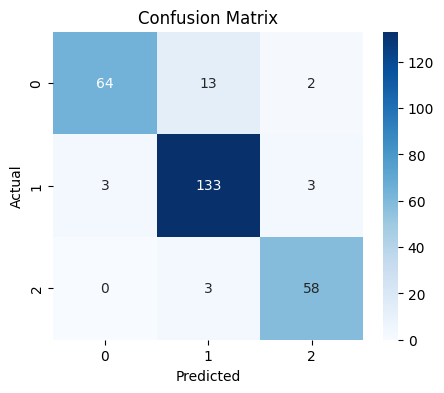

In [ ]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

Displays confusion matrix for Word2Vec NN on training data. Assesses model classification effectiveness.

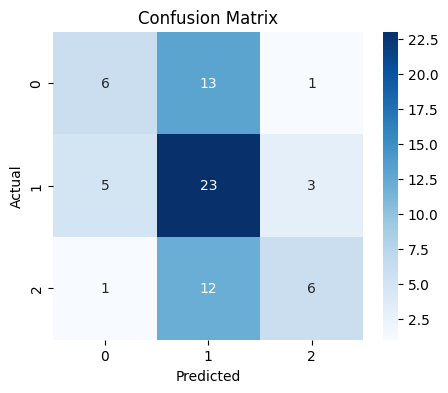

In [ ]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

Displays confusion matrix for Word2Vec NN on test data. Crucial for understanding performance on unseen data.

In [ ]:
train_Word2Vec_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_Word2Vec_NN .to_string(index=False))
test_Word2Vec_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_Word2Vec_NN .to_string(index=False))



Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.913978 0.913978    0.91647 0.912927
Test set performance metrics:
 Accuracy  Recall  Precision       F1
      0.5     0.5   0.517917 0.477324


Calculates and prints performance metrics for Word2Vec NN. Provides quantitative summary of model effectiveness.

### **Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 embedding -Neural Network model**

Details Neural Network model construction and evaluation. Uses Sentence Transformer embeddings for sentiment classification.

In [ ]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Confirms `X` is Sentence Transformer embeddings from `embedding_matrix`. Prepares feature matrix for the Neural Network.

In [ ]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

Splits Sentence Transformer embeddings and labels into train/test sets. Uses 80:20 ratio and `random_state=42` for consistent splits.

In [ ]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax') # 3 output neurons for 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,883 (417.51 KB)

 Trainable params: 106,883 (417.51 KB)

 Non-trainable params: 0 (0.00 B)

Maps sentiment labels to integers and defines NN architecture. Compiles with 'adam' and `sparse_categorical_crossentropy`.

In [ ]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.4552 - loss: 1.0820 - val_accuracy: 0.4429 - val_loss: 1.0711
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4982 - loss: 1.0275 - val_accuracy: 0.4429 - val_loss: 1.0636
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4982 - loss: 1.0049 - val_accuracy: 0.4429 - val_loss: 1.0638
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4982 - loss: 0.9902 - val_accuracy: 0.4429 - val_loss: 1.0261
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5090 - loss: 0.9533 - val_accuracy: 0.4429 - val_loss: 1.0109
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5125 - loss: 0.9158 - val_accuracy: 0.4714 - val_loss: 0.9903
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6165 - loss: 0.8699 - val_accuracy: 0.4714 - val_loss: 0.9543
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6129 - loss: 0.8279 - val_accuracy: 0.4857 - val_loss: 0.9507


Trains the Neural Network model for 20 epochs. Validation on the test set tracks training progress.

In [ ]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_pred_probs, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


Uses trained Neural Network to predict train class probabilities. Converts probabilities to discrete class labels.

In [ ]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_pred_probs, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


Generates test data predictions with trained NN model. Extracts probabilities and converts to final class labels.

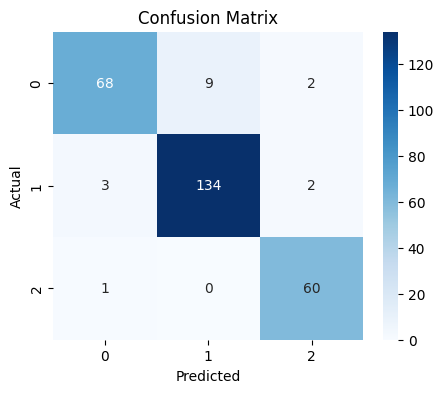

In [ ]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

Displays confusion matrix for Sentence Transformer NN on training data. Summarizes classification performance.

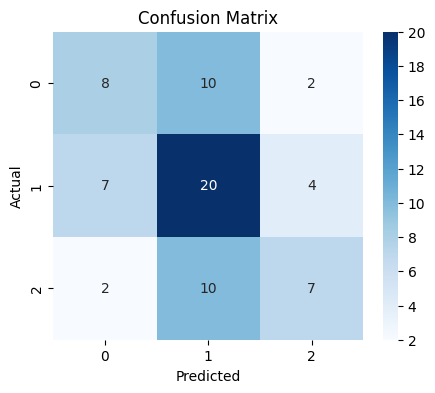

In [ ]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

Displays confusion matrix for Sentence Transformer NN on test data. Provides insights into model's generalization capabilities.

In [ ]:
train_transformer_BAAI_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_BAAI_NN .to_string(index=False))
test_transformer_BAAI_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_BAAI_NN .to_string(index=False))

Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.939068 0.939068   0.939249 0.938393
Test set performance metrics:
 Accuracy  Recall  Precision       F1
      0.5     0.5   0.502036 0.491799


Calculates and prints performance metrics for Sentence Transformer NN. Quantifies model effectiveness on train and test sets.

## **Model Performance Summary and Final Model Selection**

Consolidates test performance metrics into `models_test_comp_df`. Allows easy side-by-side model comparison.

In [ ]:
# Concatenate the test performance metrics from different models into a single DataFrame
models_test_comp_df = pd.concat(
    [
        test_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        test_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        test_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_BAAI_NN.T # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        # test_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings (commented out due to NameError)
        # test_transformer_MiniLM_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings (commented out due to NameError)
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_test_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)"
]

# Print the test performance comparison table
print("Test performance comparison:")
display(models_test_comp_df)

Test performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)
Accuracy,0.357143,0.500000,0.500000,0.500000
Recall,0.357143,0.500000,0.500000,0.500000
Precision,0.335574,0.517917,0.546509,0.502036
F1,0.304195,0.477324,0.442083,0.491799


## **Predict unseen data using Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)**

Demonstrates using the best model to predict sentiment. Uses Sentence Transformer-BAAI/bge-base-en-v1.5 Neural Network on unseen articles.

In [ ]:
print("Sample Unseen News Articles:")
display(unseen_df)

# Re-initialize the Sentence Transformer model for encoding
sentence_encoder = SentenceTransformer('BAAI/bge-base-en-v1.5')

# Encode the unseen news articles using the sentence_encoder
unseen_embeddings = sentence_encoder.encode(unseen_df['News'].tolist())

print(f"\nShape of unseen embeddings: {unseen_embeddings.shape}")

# Use the trained Neural Network model (currently stored in 'model') to predict sentiment on the unseen embeddings
unseen_pred_probs = model.predict(unseen_embeddings)
unseen_predictions_mapped = np.argmax(unseen_pred_probs, axis=1)

# Reverse the label mapping to get original sentiment labels
# This mapping should match the one used during training: -1 to 0, 0 to 1, 1 to 2
reverse_label_map = {0: -1, 1: 0, 2: 1}
unseen_predictions = np.array([reverse_label_map[p] for p in unseen_predictions_mapped])

unseen_df['Predicted_Sentiment'] = unseen_predictions

print("\nPredictions for Unseen News Articles:")
display(unseen_df)

Sample Unseen News Articles:


,News,Predicted_Sentiment
0,Apple's stock soared today after reporting record-breaking Q4 earnings and strong guidance for the next quarter. Analysts are upgrading their ratings.,1
1,"The company announced a massive recall of its flagship product due to safety concerns, causing its stock to plummet.",-1
2,"No significant news for the company today, stock prices remained stable with low trading volume.",-1
3,"Despite strong quarterly results, broader market downturns led to a slight dip in the company's stock price.",0



Shape of unseen embeddings: (4, 768)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step

Predictions for Unseen News Articles:


,News,Predicted_Sentiment
0,Apple's stock soared today after reporting record-breaking Q4 earnings and strong guidance for the next quarter. Analysts are upgrading their ratings.,1
1,"The company announced a massive recall of its flagship product due to safety concerns, causing its stock to plummet.",-1
2,"No significant news for the company today, stock prices remained stable with low trading volume.",-1
3,"Despite strong quarterly results, broader market downturns led to a slight dip in the company's stock price.",0


Demonstrates full prediction process on unseen data. Displays new articles with predicted sentiments.

## **Conclusions and Recommendations**

Summarizes key findings from model evaluations. Provides actionable suggestions for future improvements.

#### **Conclusions**

Provides conclusion on model performance and embedding techniques. Highlights best model and general observations.

**Word2Vec**
**Sentence Transformer embeddings**
**Neural Networks**
**Random Forest**

*   **Word2Vec Embeddings**: Word2Vec with Random Forest performed lowest; NN was better but still outperformed by Sentence Transformer models.
*   **Sentence Transformer (BAAI/bge-base-en-v1.5) Embeddings**: These embeddings consistently outperformed Word2Vec.
*   **Model Performance Comparison**: Sentence Transformer-BAAI/bge-base-en-v1.5 (NN) was the best performer. It achieved good balance between precision and recall on the test set.
*   **Neural Networks vs. Random Forests**: Neural Networks generally showed better F1-scores than Random Forests. This suggests NN's non-linear capabilities suit complex sentiment patterns.

#### **Recommendations**

1.  **Explore other Sentence Transformer models**: Explore `MiniLM` Sentence Transformer models for different performance or better efficiency.
2.  **Hyperparameter Tuning**: Conduct extensive hyperparameter tuning for the best Neural Network model. This could further improve performance.
3.  **Larger and More Diverse Dataset**: Expand dataset with more news articles. This can improve model generalization and robustness.
4.  **Advanced Deep Learning Architectures**: Investigate sophisticated NLP deep learning architectures. This captures nuanced contextual information.
5.  **Ensemble Methods**: Combine predictions from multiple models using ensemble techniques. This could achieve higher accuracy and robustness.
6.  **Real-time Analysis**: Integrate the best model into a real-time news feed system. This provides immediate sentiment assessment and actionable insights.

**Thank You...**

**------------------------**